# Movie Recommendation System with Explainability - Final Notebook

This notebook is the final reproducible project walkthrough. It verifies the prepared data and artifacts, reports the final MLflow-tracked evaluation, shows the ranking-NeuMF training history, and demonstrates the explainable hybrid recommender used by the Streamlit application.

The notebook intentionally does not retrain the full model by default. Final training is already logged in MLflow, and the saved model artifacts are used for evaluation and demo readiness checks.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\rafal\OneDrive\Dokumente\GitHub\Movie-Recommendation-System-with-Explainability


## 1. Data and Artifact Readiness

The final project expects raw MovieLens CSV files, processed parquet files, trained model artifacts, report outputs, and MLflow tracking data. This cell checks the files that are needed for final submission and the live demo.

In [2]:
required_paths = {
    "raw ratings": PROJECT_ROOT / "data" / "raw" / "ratings.csv",
    "raw movies": PROJECT_ROOT / "data" / "raw" / "movies.csv",
    "processed master data": PROJECT_ROOT / "data" / "processed" / "master_data_small.parquet",
    "ranking NeuMF model": PROJECT_ROOT / "models" / "neumf_ranking_model.pth",
    "ranking user encoder": PROJECT_ROOT / "models" / "ranking_user_encoder.pkl",
    "ranking item encoder": PROJECT_ROOT / "models" / "ranking_item_encoder.pkl",
    "ranking genre columns": PROJECT_ROOT / "models" / "ranking_genre_cols.pkl",
    "final top-k summary": PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv",
    "training history": PROJECT_ROOT / "reports" / "neumf_ranking_training_history.csv",
    "MLflow database": PROJECT_ROOT / "mlflow.db",
    "Streamlit app": PROJECT_ROOT / "app.py",
}

readiness = pd.DataFrame(
    [
        {"artifact": name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()}
        for name, path in required_paths.items()
    ]
)
readiness

,artifact,path,exists
0,raw ratings,data\raw\ratings.csv,True
1,raw movies,data\raw\movies.csv,True
2,processed master data,data\processed\master_data_small.parquet,True
3,ranking NeuMF model,models\neumf_ranking_model.pth,True
4,ranking user encoder,models\ranking_user_encoder.pkl,True
5,ranking item encoder,models\ranking_item_encoder.pkl,True
6,ranking genre columns,models\ranking_genre_cols.pkl,True
7,final top-k summary,reports\topk_evaluation_summary.csv,True
8,training history,reports\neumf_ranking_training_history.csv,True
9,MLflow database,mlflow.db,True


In [3]:
missing = readiness.loc[~readiness["exists"], "artifact"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required artifacts: {missing}")
print("All required final artifacts are present.")

All required final artifacts are present.


## 2. Dataset Snapshot

A compact dataset snapshot is enough here because the full exploratory analysis is already in `notebooks/eda.ipynb`.

In [4]:
ratings = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "ratings.csv")
movies = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "movies.csv")

snapshot = pd.DataFrame(
    {
        "metric": [
            "ratings",
            "users",
            "movies with ratings",
            "movies metadata rows",
            "rating min",
            "rating max",
            "rating mean",
        ],
        "value": [
            len(ratings),
            ratings["userId"].nunique(),
            ratings["movieId"].nunique(),
            len(movies),
            ratings["rating"].min(),
            ratings["rating"].max(),
            round(ratings["rating"].mean(), 3),
        ],
    }
)
snapshot

,metric,value
0,ratings,100836.000
1,users,610.000
2,movies with ratings,9724.000
3,movies metadata rows,9742.000
4,rating min,0.500
5,rating max,5.000
6,rating mean,3.502


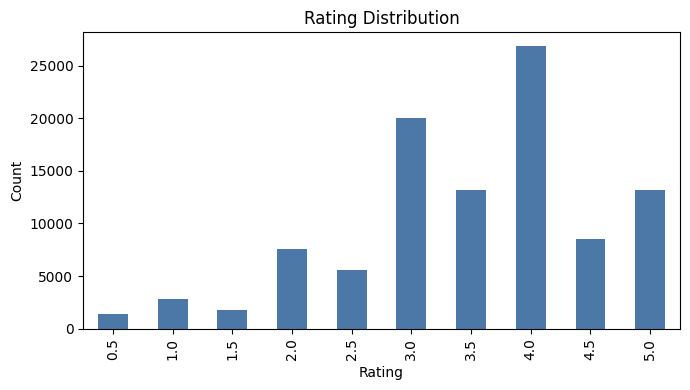

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()

## 3. Final Top-K Benchmark

The main benchmark is sampled top-K recommendation quality. It uses a temporal per-user split, held-out positives with `rating >= 4.0`, and 100 sampled unseen negatives per evaluated user. The primary metric is `NDCG@10`.

In [6]:
summary_path = PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv"
summary = pd.read_csv(summary_path)
metric_cols = [col for col in summary.columns if col != "recommender"]
summary[metric_cols] = summary[metric_cols].round(4)
summary.sort_values("ndcg@10", ascending=False).reset_index(drop=True)

,recommender,precision@5,recall@5,hit_rate@5,ndcg@5,precision@10,recall@10,hit_rate@10,ndcg@10
0,hybrid_ranker,0.478,0.3386,0.90,0.5538,0.397,0.5041,0.95,0.5843
1,neumf_ranking_model,0.486,0.3015,0.87,0.5370,0.415,0.4846,0.91,0.5686
2,item_item_knn,0.448,0.3171,0.84,0.5016,0.382,0.4832,0.94,0.5409
3,popularity_bayes,0.398,0.2478,0.78,0.4575,0.330,0.3813,0.85,0.4731
4,genre_personalized_popularity,0.414,0.2833,0.86,0.4834,0.312,0.3726,0.88,0.4689
5,neumf_rating_model,0.182,0.1121,0.53,0.2047,0.187,0.2012,0.71,0.2389
6,random,0.108,0.0592,0.40,0.1210,0.104,0.1196,0.62,0.1359


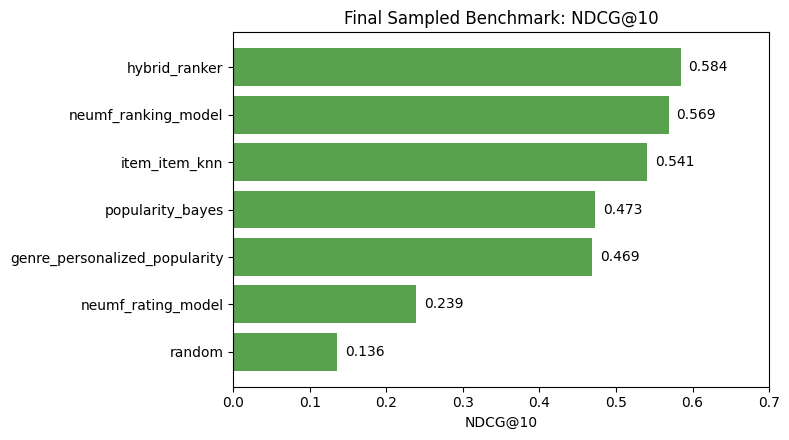

In [7]:
ranked_summary = summary.sort_values("ndcg@10", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(ranked_summary["recommender"], ranked_summary["ndcg@10"], color="#59A14F")
ax.set_title("Final Sampled Benchmark: NDCG@10")
ax.set_xlabel("NDCG@10")
ax.set_xlim(0, max(0.7, ranked_summary["ndcg@10"].max() + 0.05))
for index, value in enumerate(ranked_summary["ndcg@10"]):
    ax.text(value + 0.01, index, f"{value:.3f}", va="center")
plt.tight_layout()

In [8]:
best_row = summary.sort_values("ndcg@10", ascending=False).iloc[0]
print(
    f"Best final logged sampled benchmark model: {best_row['recommender']} "
    f"with NDCG@10={best_row['ndcg@10']:.4f}."
)

neural_row = summary[summary["recommender"].eq("neumf_ranking_model")]
if not neural_row.empty:
    neural_row = neural_row.iloc[0]
    print(
        f"Best neural model: neumf_ranking_model with "
        f"NDCG@10={neural_row['ndcg@10']:.4f}."
    )

Best final logged sampled benchmark model: hybrid_ranker with NDCG@10=0.5843.
Best neural model: neumf_ranking_model with NDCG@10=0.5686.


## 4. Ranking NeuMF Training History

The original NeuMF was a rating-prediction model. The final NeuMF variant is trained as a ranking model with sampled negatives and `BCEWithLogitsLoss`, then evaluated with top-K metrics during training.

In [9]:
history_path = PROJECT_ROOT / "reports" / "neumf_ranking_training_history.csv"
history = pd.read_csv(history_path)
history.round(4)

,epoch,loss,precision@10,recall@10,hit_rate@10,ndcg@10,is_best
0,1,0.5845,0.148,0.1256,0.63,0.1755,True
1,2,0.4605,0.247,0.2502,0.80,0.3319,True
2,3,0.4189,0.341,0.3660,0.88,0.4566,True
3,4,0.3772,0.395,0.4405,0.89,0.5371,True
4,5,0.3376,0.423,0.5182,0.94,0.5914,True


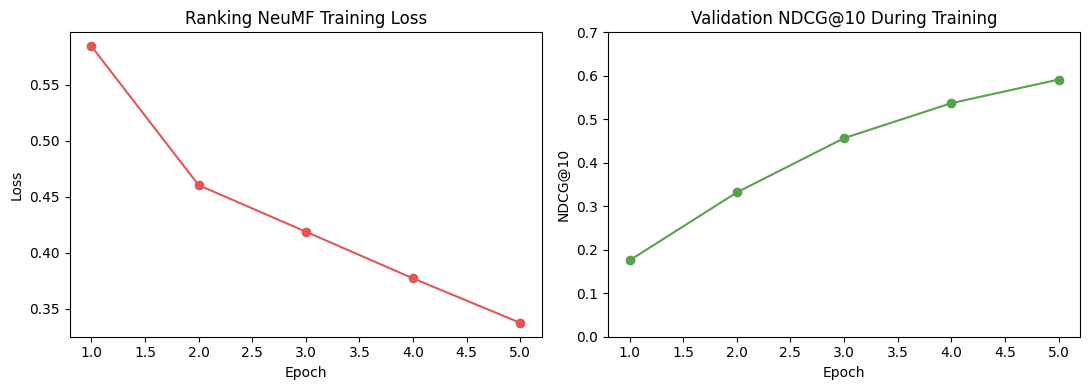

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history.plot(x="epoch", y="loss", marker="o", ax=axes[0], color="#E15759", legend=False)
axes[0].set_title("Ranking NeuMF Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

history.plot(x="epoch", y="ndcg@10", marker="o", ax=axes[1], color="#59A14F", legend=False)
axes[1].set_title("Validation NDCG@10 During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NDCG@10")
axes[1].set_ylim(0, max(0.7, history["ndcg@10"].max() + 0.05))
plt.tight_layout()

## 5. MLflow Tracking Artifacts

Final training and evaluation were logged with MLflow during project development. The local MLflow database can be opened with:

```powershell
python -m mlflow ui --backend-store-uri sqlite:///mlflow.db
```

For notebook reproducibility, this section does not query the MLflow database directly. Local MLflow SQLite databases can be version-sensitive: if the installed MLflow package expects a different schema, direct database queries may fail even though the saved project results are valid. Instead, the notebook verifies the saved MLflow artifact folders and displays the exported CSV reports that were logged during the final run.

In [11]:
mlruns_dir = PROJECT_ROOT / "mlruns"
training_artifacts = sorted(mlruns_dir.glob("2/*/artifacts/ranking_neumf"))
evaluation_artifacts = sorted(mlruns_dir.glob("3/*/artifacts/evaluation"))

mlflow_artifact_check = pd.DataFrame(
    [
        {
            "artifact_group": "ranking NeuMF training artifacts",
            "found": bool(training_artifacts),
            "example_path": str(training_artifacts[-1].relative_to(PROJECT_ROOT)) if training_artifacts else "not found",
        },
        {
            "artifact_group": "top-K evaluation artifacts",
            "found": bool(evaluation_artifacts),
            "example_path": str(evaluation_artifacts[-1].relative_to(PROJECT_ROOT)) if evaluation_artifacts else "not found",
        },
    ]
)
display(mlflow_artifact_check)

print("Final evaluation summary exported from the logged run:")
display(pd.read_csv(PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv"))

leaderboard_path = PROJECT_ROOT / "reports" / "evaluation_runs" / "leaderboard.csv"
if leaderboard_path.exists():
    leaderboard = pd.read_csv(leaderboard_path)
    sort_col = "run_timestamp" if "run_timestamp" in leaderboard.columns else None
    if sort_col:
        leaderboard = leaderboard.sort_values(sort_col, ascending=False)
    display_cols = [
        col for col in [
            "run_id",
            "run_timestamp",
            "run_label",
            "recommender",
            "ndcg@10",
            "precision@10",
            "recall@10",
            "hit_rate@10",
        ]
        if col in leaderboard.columns
    ]
    display(leaderboard.head(10)[display_cols])
else:
    print("No leaderboard file found.")

,artifact_group,found,example_path
0,ranking NeuMF training artifacts,True,mlruns\2\d4870608b3e844e08e1053c7bb91bc6f\arti...
1,top-K evaluation artifacts,True,mlruns\3\b34aff93db674a5b81eecadde20d21a3\arti...


Final evaluation summary exported from the logged run:


,recommender,precision@5,recall@5,hit_rate@5,ndcg@5,precision@10,recall@10,hit_rate@10,ndcg@10
0,genre_personalized_popularity,0.414,0.283345,0.86,0.483428,0.312,0.372643,0.88,0.468950
1,hybrid_ranker,0.478,0.338605,0.90,0.553787,0.397,0.504098,0.95,0.584258
2,item_item_knn,0.448,0.317115,0.84,0.501596,0.382,0.483245,0.94,0.540862
3,neumf_ranking_model,0.486,0.301475,0.87,0.537005,0.415,0.484638,0.91,0.568627
4,neumf_rating_model,0.182,0.112126,0.53,0.204672,0.187,0.201209,0.71,0.238934
5,popularity_bayes,0.398,0.247829,0.78,0.457509,0.330,0.381300,0.85,0.473149
6,random,0.108,0.059232,0.40,0.120951,0.104,0.119565,0.62,0.135858


,run_id,run_timestamp,run_label,recommender,ndcg@10,precision@10,recall@10,hit_rate@10
64,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,random,0.135858,0.104,0.119565,0.62
63,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,popularity_bayes,0.473149,0.330,0.381300,0.85
62,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,neumf_rating_model,0.238934,0.187,0.201209,0.71
61,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,neumf_ranking_model,0.568627,0.415,0.484638,0.91
60,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,item_item_knn,0.540862,0.382,0.483245,0.94
59,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,hybrid_ranker,0.584258,0.397,0.504098,0.95
58,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,genre_personalized_popularity,0.468950,0.312,0.372643,0.88
54,topk_final_mlflow_logged_sampled_100_negatives...,2026-06-04 20:47:41,final_mlflow_logged,neumf_ranking_model,0.568627,0.415,0.484638,0.91
51,topk_final_mlflow_logged_sampled_100_negatives...,2026-06-04 20:47:41,final_mlflow_logged,genre_personalized_popularity,0.468950,0.312,0.372643,0.88
52,topk_final_mlflow_logged_sampled_100_negatives...,2026-06-04 20:47:41,final_mlflow_logged,hybrid_ranker,0.584258,0.397,0.504098,0.95


## 6. Interpretability Strategy

Interpretability is treated as a core part of the recommender design, not as a separate visualization added after the model is finished. The project uses model-specific explanations first because they are easier to validate and easier for a user to understand than explanations over hidden embedding dimensions.

### Item-Item KNN explanations

The item-item KNN model recommends movies by comparing candidate movies with movies the user has already liked. Its explanation is therefore direct: a movie is recommended because it is similar to specific movies in the user's positive history. This is useful for the live demo because it gives concrete evidence such as: "recommended because you liked these similar movies." The explanation is faithful to the model because the same similarity scores used for ranking are shown as evidence.

### Hybrid ranker explanations

The final Streamlit app uses the hybrid ranker. This model combines three interpretable signals:

- item-item KNN similarity: collaborative signal based on similar liked movies
- Bayesian-smoothed popularity: global quality and reliability signal
- genre affinity: content signal based on the user's preferred genres

The final recommendation score is a weighted combination of these components. This makes the explanation naturally decomposable: for every recommendation we can show how much came from item similarity, popularity, and genre match. This is the most useful explanation layer for the final application because it connects the ranking result to understandable recommendation logic.

### Ranking NeuMF explanations

The ranking NeuMF model is useful as a strong neural benchmark, but its internal embeddings are not directly human-readable. For this reason, the notebook and application avoid presenting embedding dimensions as explanations. A safer model-specific explanation is genre occlusion sensitivity: we can estimate how the neural score changes when genre information is altered. This does not fully explain the latent collaborative embeddings, but it gives a reasonable sensitivity-based view of which content features influence the score.

### Why SHAP is limited to the final hybrid model

SHAP is most meaningful here when applied to structured, human-readable features. For this project, SHAP-style attribution is used only on the final hybrid ranker's structured features: item KNN score, popularity score, and genre score. This avoids the common problem of explaining latent neural embedding dimensions that do not have clear semantic meaning. In other words, SHAP is used where the feature space is understandable, while model-specific explanations are preferred everywhere else.

### Final interpretability conclusion

The final explanation approach is faithful, practical, and demo-ready. Item-item KNN provides evidence from similar liked movies. The hybrid model provides component-level score decomposition. The neural model is treated mainly as a benchmark, with sensitivity analysis available when needed. This gives the project both strong recommendation quality and explanations that a non-technical user can understand.

## 7. Explainable Recommendation Demo

The Streamlit app uses the hybrid ranker. It combines item-item KNN similarity, Bayesian-smoothed popularity, genre affinity, and optional diversity reranking. The explanation uses model-specific evidence first: similar movies the user liked plus explicit component contributions.

In [12]:
from src.hybrid_ranker import HybridRanker

ranker = HybridRanker(diversity_weight=0.05)
user_id = ranker.available_user_ids()[0]
liked = ranker.user_liked_movies(user_id, limit=5)
recommendations = ranker.recommend_for_user(user_id=user_id, top_n=5, diversity_weight=0.05)

print(f"Demo user: {user_id}")
print("Recently liked/high-rated movies used as evidence:")
display(liked)

cols = [
    "title",
    "genres",
    "relevance_score",
    "item_knn_score",
    "popularity_score",
    "genre_score",
    "explanation_summary",
]
display(recommendations[cols])

Demo user: 1
Recently liked/high-rated movies used as evidence:


,movieId,title,rating
0,2959,Fight Club (1999),5.0
1,2329,American History X (1998),5.0
2,954,Mr. Smith Goes to Washington (1939),5.0
3,2387,Very Bad Things (1998),5.0
4,1804,"Newton Boys, The (1998)",5.0


,title,genres,relevance_score,item_knn_score,popularity_score,genre_score,explanation_summary
0,For Your Eyes Only (1981),Action | Adventure | Thriller,0.8430,1.0000,0.5885,0.7836,Main signal: similarity to movies the user liked.
1,"Lord of the Rings: The Return of the King, The...",Action | Adventure | Drama | Fantasy,0.7839,0.6982,0.8680,0.8713,Main signal: similarity to movies the user liked.
2,"Spy Who Loved Me, The (1977)",Action | Adventure | Thriller,0.7871,0.8839,0.5968,0.7836,Main signal: similarity to movies the user liked.
3,Licence to Kill (1989),Action | Adventure | Thriller,0.7794,0.8944,0.5449,0.7836,Main signal: similarity to movies the user liked.
4,Austin Powers: The Spy Who Shagged Me (1999),Action | Adventure | Comedy,0.7617,0.8291,0.4970,0.8917,Main signal: similarity to movies the user liked.


In [13]:
first = recommendations.iloc[0]
print(f"Top recommendation: {first['title']}")
print(first["explanation_summary"])

print()
print("Similar liked movies that support this recommendation:")
for item in first["explanations"]:
    print(f"- {item['title']} (similarity={item['similarity']:.3f})")

print()
print("Hybrid component contributions:")
contributions = first["component_contributions"]
if isinstance(contributions, dict):
    contribution_rows = []
    for component, value in contributions.items():
        if isinstance(value, dict):
            row = {"component": component, **value}
        else:
            row = {"component": component, "value": value}
        contribution_rows.append(row)
    display(pd.DataFrame(contribution_rows))
else:
    display(pd.DataFrame(contributions))

Top recommendation: For Your Eyes Only (1981)
Main signal: similarity to movies the user liked.

Similar liked movies that support this recommendation:
- Thunderball (1965) (similarity=0.756)
- From Russia with Love (1963) (similarity=0.624)
- Dr. No (1962) (similarity=0.516)

Hybrid component contributions:


,component,item_knn,popularity,genre,value
0,contributions,0.5,0.147125,0.1959,NaN
1,total,NaN,NaN,NaN,0.843025
2,top_component,NaN,NaN,NaN,item_knn


## 8. Final Conclusion

The final project is ready from a modeling perspective:

- The final benchmark is `eval_topk`, with historical run tracking under `reports/evaluation_runs/`.
- Final training and evaluation results are logged in MLflow.
- The strongest final logged sampled benchmark model is the hybrid ranker.
- The strongest neural model is the retrained ranking NeuMF.
- The Streamlit app uses the hybrid ranker because it performs best in the final logged sampled benchmark and provides clear explanations.
- Interpretability is model-specific first, with SHAP-style structured feature attribution reserved for the final hybrid ranker.

Recommended final submission step: rehearse the Streamlit demo once and capture screenshots for the final presentation/report.